In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import pandas as pd

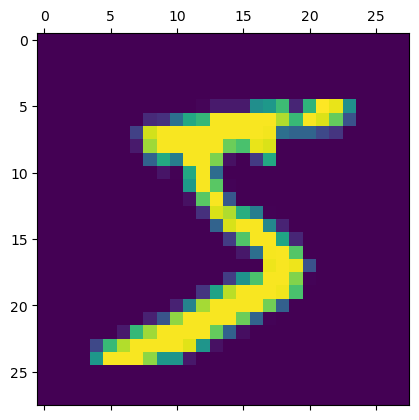

In [9]:
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()
plt.matshow(X_train[0])

In [15]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(200, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
              metrics= ['accuracy']
             )

model.fit(X_train, y_train, epochs=5)
predictions=model.predict(X_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8863 - loss: 1.4885
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9401 - loss: 0.2438
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9544 - loss: 0.1641
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9574 - loss: 0.1517
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9625 - loss: 0.1330
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
import seaborn as sn
from sklearn.metrics import confusion_matrix

y_predictions=np.argmax(predictions, axis=1)
cm=confusion_matrix(y_test, y_predictions)
cm

array([[ 953,    0,    7,    0,    1,    5,    9,    2,    2,    1],
       [   0, 1123,    2,    1,    1,    3,    1,    0,    4,    0],
       [   1,    8,  982,   12,    1,    0,    2,    8,   17,    1],
       [   0,    2,    6,  954,    0,   11,    0,    6,   28,    3],
       [   1,    0,    0,    1,  948,    0,    8,    7,    0,   17],
       [   3,    1,    0,    5,    2,  851,    7,    1,   16,    6],
       [   3,    3,    0,    0,    4,   12,  928,    0,    8,    0],
       [   2,    9,   13,    2,    5,    0,    0,  977,    3,   17],
       [   4,    2,    2,    5,    4,    8,    4,    3,  938,    4],
       [   6,    5,    1,    6,   15,    4,    0,    7,   15,  950]])

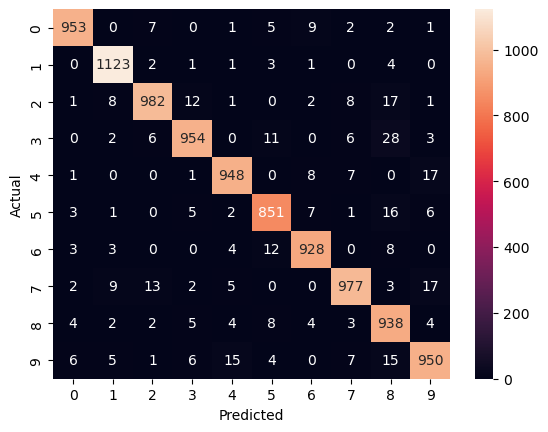

In [17]:
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()